In [5]:
import sys
sys.path.append('../utils')
from utils_models import *


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

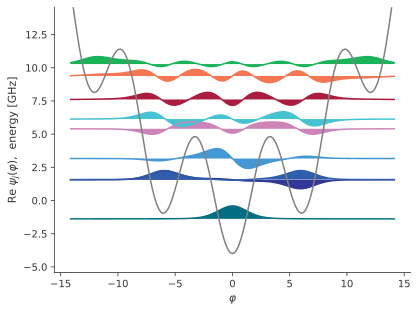

In [26]:
EJ = 4
EC = 4/4
EL = 4/25
fluxonium = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=20)


fluxonium.plot_wavefunction(which=[0,1,2,3,4,5,6,7,8])

In [6]:

freq = {
    'g0g1':[],
    'e0e1':[],
    'f0f1':[],
    'g1g2':[],
    'e1e2':[],
    'f1f2':[]
}

me = {
    'g1g2':[],
    'e1e2':[],
    'f1f2':[]
}

tmon_freq = []
for t_EJ in tqdm(np.linspace(10,50,200)):


    transmon = scqubits.Transmon(
        EJ=t_EJ,
        EC=0.2,
        ng=0.0,
        ncut=10,
        truncated_dim = 4
        )

    system = FluxoniumTransmonSystem(
        fluxonium  = fluxonium,
        transmon = transmon,
        computaional_states = '1,2',
        g_strength = 0.2,
        )

    def dressed_ener(ql,ol):
        return system.evals[system.product_to_dressed[(ql,ol)]]
    ols = system.transmon.truncated_dim
    op = system.hilbertspace.op_in_dressed_eigenbasis(transmon.n_operator)

    tmon_freq.append(transmon.eigenvals()[1]-transmon.eigenvals()[0])
    freq['g1g2'].append(dressed_ener(0,2)-dressed_ener(0,1))
    freq['e1e2'].append(dressed_ener(1,2)-dressed_ener(1,1))
    freq['f1f2'].append(dressed_ener(2,2)-dressed_ener(2,1))

    freq['g0g1'].append(dressed_ener(0,1)-dressed_ener(0,0))
    freq['e0e1'].append(dressed_ener(1,1)-dressed_ener(1,0))
    freq['f0f1'].append(dressed_ener(2,1)-dressed_ener(2,0))

    me['g1g2'].append(abs(op[system.product_to_dressed[(0,1)],  system.product_to_dressed[(0,2)]]))
    me['e1e2'].append(abs(op[system.product_to_dressed[(1,1)],  system.product_to_dressed[(1,2)]]))
    me['f1f2'].append(abs(op[system.product_to_dressed[(2,1)],  system.product_to_dressed[(2,2)]]))


100%|██████████| 200/200 [01:49<00:00,  1.82it/s]


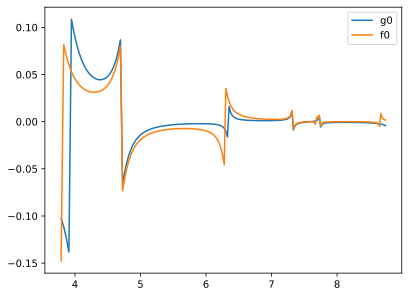

In [8]:
plt.plot(np.array(tmon_freq),np.array(freq['g0g1'])-np.array(freq['e0e1']),label='g0')
plt.plot(np.array(tmon_freq),np.array(freq['f0f1'])-np.array(freq['e0e1']),label='f0')

plt.legend()

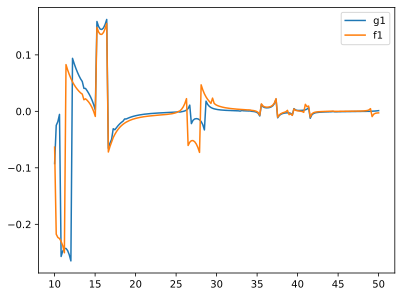

In [16]:
plt.plot(np.linspace(10,50,200),np.array(freq['g1g2'])-np.array(freq['e1e2']),label='g1')
plt.plot(np.linspace(10,50,200),np.array(freq['f1f2'])-np.array(freq['e1e2']),label='f1')

plt.legend()

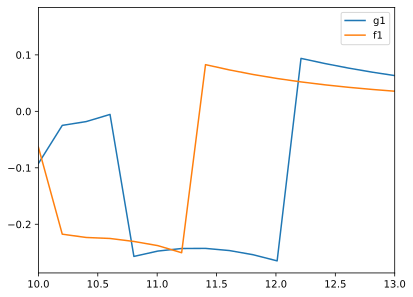

In [20]:
plt.plot(np.linspace(10,50,200),np.array(freq['g1g2'])-np.array(freq['e1e2']),label='g1')
plt.plot(np.linspace(10,50,200),np.array(freq['f1f2'])-np.array(freq['e1e2']),label='f1')

plt.xlim(10,13)
plt.legend()

In [21]:
EJ = 4
EC = 4/5.9
EL = 4/29.2
fluxonium = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=20)

transmon = scqubits.Transmon(
    EJ=11.65,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = 4
    )

system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '0,2',
    g_strength = 0.2,
    )


# Control

In [22]:
system.evals[system.product_to_dressed[(0,2)]]-system.evals[system.product_to_dressed[(0,1)]], \
system.evals[system.product_to_dressed[(1,2)]]-system.evals[system.product_to_dressed[(1,1)]], \
system.evals[system.product_to_dressed[(2,2)]]-system.evals[system.product_to_dressed[(2,1)]]

(3.6555660822359393, 3.9033445346364957, 3.974899223004268)

# Probe

In [23]:
system.evals[system.product_to_dressed[(0,1)]]-system.evals[system.product_to_dressed[(0,0)]], \
system.evals[system.product_to_dressed[(1,1)]]-system.evals[system.product_to_dressed[(1,0)]], \
system.evals[system.product_to_dressed[(2,1)]]-system.evals[system.product_to_dressed[(2,0)]]

(4.177070796300676, 4.1124491979732145, 4.1486769202766425)

In [28]:
initial_states = [
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,0)])
]

e_ops = []
for ql in range(3):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))

# Get the Raman pi pulse parameters
op = system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)


length = 200


aera_probe = np.pi  * 0.3
amplitude_g01 = aera_probe/( length * abs(op[system.product_to_dressed[(0,1)],  system.product_to_dressed[(0,0)]])   )
amplitude_e01 = aera_probe/( length * abs(op[system.product_to_dressed[(1,1)],  system.product_to_dressed[(1,0)]])   )
amplitude_f01 = aera_probe/( length * abs(op[system.product_to_dressed[(2,1)],  system.product_to_dressed[(2,0)]])   )

amplitude_g01, amplitude_e01,amplitude_f01

(0.0047665226259890345, 0.004256391117281247, 0.004431288012043089)

 Total run time:   1.40s*] Elapsed 1.40s / Remaining 00:00:00:00 [*********65%***        ] Elapsed 1.05s / Remaining 00:00:00:00
 Total run time:   1.40s*] Elapsed 1.40s / Remaining 00:00:00:00
 Total run time:   1.66s*] Elapsed 1.65s / Remaining 00:00:00:00


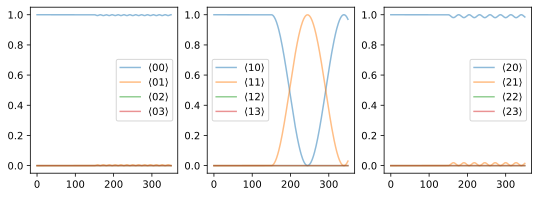

In [30]:
length = 350
tlist = np.linspace(0,length,int(length))
Delta = 0
results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            # probe
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(1,1)]] - system.evals[system.product_to_dressed[(1,0)]] +Delta/(2*np.pi),
                    'amp1':amplitude_g01,
                    't_rise1': 1e-5,
                    't_square1': 1000,
                    't_start1': 150
                  },
                ),

            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()

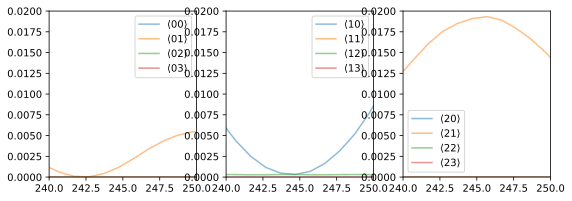

In [35]:
fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()
    axes[i].set_ylim(0,0.02)
    axes[i].set_xlim(240,250)

 Total run time:   2.40s*] Elapsed 2.40s / Remaining 00:00:00:000[*********95%********** ] Elapsed 2.27s / Remaining 00:00:00:00
 Total run time:   2.41s*] Elapsed 2.41s / Remaining 00:00:00:00
 Total run time:   2.75s*] Elapsed 2.75s / Remaining 00:00:00:00


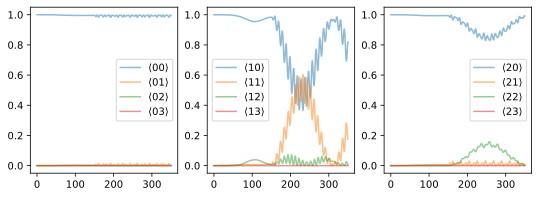

In [38]:
length = 350
tlist = np.linspace(0,length,int(length))
Delta = 0

results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            # EIT drive 1 
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(2,2)]]-system.evals[system.product_to_dressed[(1,1)]] - Delta/(2*np.pi),
                    'amp': 0.02,
                    't_rise':  100,
                    't_square': 1000,
                    't_start': 0
                  },
                ),


            # probe
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(1,1)]] - system.evals[system.product_to_dressed[(1,0)]] +Delta/(2*np.pi),
                    'amp1':amplitude_e01,
                    't_rise1': 1e-5,
                    't_square1': 1000,
                    't_start1': 150
                  },
                ),

            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()